In [60]:
from datetime import datetime
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import expm
from scipy.linalg import expm, circulant
import scipy.sparse as sp
from scipy.linalg import solve_circulant

In [2]:
def spectral_expansion(v,N):
    # N is number of points I want to map to
    ## vv is the coefficients associated with wavelengths from a lower spatial resolution
    vlen = int(len(v)/2)
    v_expanded = np.zeros(N, dtype=complex)
    v_expanded[:(vlen)] = v[:(vlen)]
    v_expanded[-(vlen):] = v[-(vlen):]
    return v_expanded

In [3]:


def ks_equation(N, h = 1/4):
    
    time_start = time.time()
    x = 32 * np.pi * np.arange(1, N+1) / N
    u = np.cos(x/16) * (1 + np.sin(x/16))
    v = np.fft.fft(u)

    # Precompute various ETDRK4 scalar quantities
    h = 1/4  # time step
    k = np.concatenate([ np.arange(0, N//2), [0], np.arange(-N//2+1, 0)]) / 16  # wave numbers
    L = k**2 - k**4  # Fourier multipliers
    E = np.exp(h * L)
    E2 = np.exp(h * L / 2)
    M = 16  # number of points for complex means
    r = np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)  # roots of unity

    LR = h * L[:, None] + r[None, :]
    Q = h * np.real(np.mean((np.exp(LR / 2) - 1) / LR, axis=1))
    f1 = h * np.real(np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR**2)) / LR**3, axis=1))
    f2 = h * np.real(np.mean((2 + LR + np.exp(LR) * (-2 + LR)) / LR**3, axis=1))
    f3 = h * np.real(np.mean((-4 - 3 * LR - LR**2 + np.exp(LR) * (4 - LR)) / LR**3, axis=1))

    # Main time-stepping loop
    uu = u
    vv = v


    tt = [0]
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor(nmax / 100)))
    g = -0.5j * k





    for n in range(1, nmax+1):
        t = n * h
        Nv = g * np.fft.fft(np.real(np.fft.ifft(v))**2)
        a = E2 * v + Q * Nv
        Na = g * np.fft.fft(np.real(np.fft.ifft(a))**2)
        b = E2 * v + Q * Na
        Nb = g * np.fft.fft(np.real(np.fft.ifft(b))**2)
        c = E2 * a + Q * (2 * Nb - Nv)
        Nc = g * np.fft.fft(np.real(np.fft.ifft(c))**2)
        
        v = E * v + Nv * f1 + 2 * (Na + Nb) * f2 + Nc * f3
        
        if n % nplt == 0:
            u = np.real(np.fft.ifft(v))
            uu = np.vstack([uu, u])

            vv = np.vstack([vv, v])
            tt.append(t)
    
    time_end = time.time()
    elapsed_time = time_end - time_start
    print(f"KS equation simulation completed in {elapsed_time:.2f} seconds.")
    
    
    return [x, tt, uu, vv, elapsed_time]

In [126]:
N = 1000
h = 1/4


##FDM quantities
##Discretise space:
x = 32*np.pi*np.arange(1,N+1)/N
dx = x[1] - x[0]
##set initial conditions
u = np.cos(x/16) * (1 + np.sin(x/16))
## Differentiation matrices plus identity:
D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()


D1[0,-1] = -1
D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
D4[-1,0] = D4[0,-1] = -4

D1 = D1/(2*dx)
D2 = D2/(dx**2)
D4 = D4/(dx**4)
print("Linear operator constructed. Computing ETD-RK4 coefficients...")

I = np.eye(N)
##Linear operator L:
L = -(D2+D4)


##ETD quantities

M = 64

r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

A = h * L
E_a = expm(A)
E2_a = expm(A / 2)

I = np.eye(N)
Z = np.zeros((N, N))

f1_a = Z.copy()
f2_a = Z.copy()
f3_a = Z.copy()
Q_a = Z.copy()
print("Computing ETD-RK4 coefficients...")
for j in range(M):
    z = r[j]
    
    zIA = np.linalg.inv(z * I - A)
    
    
    
    Q_a  = Q_a + h * zIA * (np.exp(z/2) - 1)
    f1_a = f1_a + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
    f2_a = f2_a + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
    f3_a = f3_a + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

Q_a  = np.real(Q_a)/M
f1_a = np.real(f1_a)/M
f2_a = np.real(f2_a)/M
f3_a = np.real(f3_a)/M

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...


In [127]:

##FDM quantities
##Discretise space:
x = 32*np.pi*np.arange(1,N+1)/N
dx = x[1] - x[0]
##set initial conditions
u = np.cos(x/16) * (1 + np.sin(x/16))
## Differentiation matrices plus identity:
D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

D1[0,-1] = -1
D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
D4[-1,0] = D4[0,-1] = -4

D1 = D1/(2*dx)
D2 = D2/(dx**2)
D4 = D4/(dx**4)
print("Linear operator constructed. Computing ETD-RK4 coefficients...")

I = np.eye(N)
##Linear operator L:
L = -(D2+D4)

##ETD quantities

M = 64

r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

A = h * L

# FFT eigenvalues of circulant A
A_first_col = A[:, 0].astype(complex)
lamA = np.fft.fft(A_first_col)

E_b = np.real(circulant(np.fft.ifft(np.exp(lamA))))
E2_b = np.real(circulant(np.fft.ifft(np.exp(lamA / 2))))

def circulant_inverse_from_Aeig(z, lamA):
    denom = z - lamA
    inv_first_col = np.fft.ifft(1.0 / denom)
    return circulant(inv_first_col)


Z = np.zeros(N, dtype=complex)

f1_b = Z.copy()
f2_b = Z.copy()
f3_b = Z.copy()
Q_b  = Z.copy()
print("Computing ETD-RK4 coefficients...")
for j in range(M):
    z = r[j]
    denom = z - lamA
    inverse_eig = 1.0 / denom
    
    
    Q_b  = Q_b + h * inverse_eig * (np.exp(z/2) - 1)
    f1_b = f1_b + h * inverse_eig * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
    f2_b = f2_b + h * inverse_eig * (2 + z + np.exp(z)*(z - 2)) / z**2
    f3_b = f3_b + h * inverse_eig * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

Q_b  = Q_b/M
f1_b = f1_b/M
f2_b = f2_b/M
f3_b = f3_b/M

Q_b = np.real(circulant(np.fft.ifft(Q_b)))
f1_b = np.real(circulant(np.fft.ifft(f1_b)))
f2_b = np.real(circulant(np.fft.ifft(f2_b)))
f3_b = np.real(circulant(np.fft.ifft(f3_b)))

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...


In [148]:
np.linalg.norm(Q_a - Q_b)

np.float64(4.4349314123087007e-13)

In [131]:
v = np.random.rand(N)

In [144]:
time_start = time.time()
Q_a@v
time_end = time.time()
print(f"Time for direct matrix-vector product: {time_end - time_start:.6f} seconds")

Time for direct matrix-vector product: 0.000611 seconds


In [143]:
time_start = time.time()
Q_b@v
time_end = time.time()
print(f"Time for circulant matrix-vector product: {time_end - time_start:.6f} seconds")

Time for circulant matrix-vector product: 0.001123 seconds


In [145]:
print(Q_a.dtype, Q_a.flags["C_CONTIGUOUS"])
Q_a = np.ascontiguousarray(Q_a, dtype=np.float64)

float64 True


In [147]:
print(Q_b.dtype, Q_b.flags["C_CONTIGUOUS"])
Q_b = np.ascontiguousarray(Q_b, dtype=np.float64)
print(Q_b.dtype, Q_b.flags["C_CONTIGUOUS"])

float64 True
float64 True


In [149]:
def ETDFDM_KS_FFT(N,h = 1/4):
    time_start = time.time()

    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")

    I = np.eye(N)
    ##Linear operator L:
    L = -(D2+D4)

    ##ETD quantities

    M = 64

    r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    
    # FFT eigenvalues of circulant A
    A_first_col = A[:, 0].astype(complex)
    lamA = np.fft.fft(A_first_col)
    
    E = np.ascontiguousarray(np.real(circulant(np.fft.ifft(np.exp(lamA)))), dtype=np.float64)
    E2 = np.ascontiguousarray(np.real(circulant(np.fft.ifft(np.exp(lamA / 2)))), dtype=np.float64)
    
    def circulant_inverse_from_Aeig(z, lamA):
        denom = z - lamA
        inv_first_col = np.fft.ifft(1.0 / denom)
        return circulant(inv_first_col)

    
    Z = np.zeros(N, dtype=complex)

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()
    print("Computing ETD-RK4 coefficients...")
    for j in range(M):
        z = r[j]
        denom = z - lamA
        inverse_eig = 1.0 / denom
        
        
        Q  = Q + h * inverse_eig * (np.exp(z/2) - 1)
        f1 = f1 + h * inverse_eig * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * inverse_eig * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * inverse_eig * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = Q/M
    f1 = f1/M
    f2 = f2/M
    f3 = f3/M
    
    Q = np.ascontiguousarray(np.real(circulant(np.fft.ifft(Q))), dtype=np.float64)
    f1 = np.ascontiguousarray(np.real(circulant(np.fft.ifft(f1))), dtype=np.float64)
    f2 = np.ascontiguousarray(np.real(circulant(np.fft.ifft(f2))), dtype=np.float64)
    f3 = np.ascontiguousarray(np.real(circulant(np.fft.ifft(f3))), dtype=np.float64)
    

    print("ETD-RK4 coefficients computed. Starting time-stepping...")
    print("E eigenvalues:", np.max(np.abs(np.linalg.eigvalsh(E))))
    print("Q max value:", np.max(np.abs(Q)))
    print("E2 max value:", np.max(np.abs(E2)))
    print("Any NaNs in Q?", np.any(np.isnan(Q)))
    

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor((tmax / 100) / h)))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h

        Nu = -u*(D1@u)
        a  = E2 @ u + Q @ Nu
        Na = -a*(D1@a)

        b  = E2 @ u + Q @ Na
        Nb = -b*(D1@b)
        
        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = -c*(D1@c)

        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        if n % nplt == 0:
            #print("Saving at t = ", t)
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            if n%(10*nplt) == 0:
                print("you have completed", n/nmax)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_KS execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]

In [96]:
def ETDFDM_KS(N,h = 1/4):
    time_start = time.time()

    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    
    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")

    I = np.eye(N)
    ##Linear operator L:
    L = -(D2+D4)
    

    ##ETD quantities

    M = 64

    r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    E = expm(A)
    E2 = expm(A / 2)

    I = np.eye(N)
    Z = np.zeros((N, N))

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()
    print("Computing ETD-RK4 coefficients...")
    for j in range(M):
        z = r[j]
        
        zIA = np.linalg.inv(z * I - A)
        
        
        
        Q  = Q + h * zIA * (np.exp(z/2) - 1)
        f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = np.real(Q)/M
    f1 = np.real(f1)/M
    f2 = np.real(f2)/M
    f3 = np.real(f3)/M


    print("ETD-RK4 coefficients computed. Starting time-stepping...")
    print("E eigenvalues:", np.max(np.abs(np.linalg.eigvalsh(E))))
    print("Q max value:", np.max(np.abs(Q)))
    print("E2 max value:", np.max(np.abs(E2)))
    print("Any NaNs in Q?", np.any(np.isnan(Q)))
    

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor((tmax / 100) / h)))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h

        Nu = -u*(D1@u)
        a  = E2 @ u + Q @ Nu
        Na = -a*(D1@a)

        b  = E2 @ u + Q @ Na
        Nb = -b*(D1@b)
        
        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = -c*(D1@c)

        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        if n % nplt == 0:
            #print("Saving at t = ", t)
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            if n%(10*nplt) == 0:
                print("you have completed", n/nmax)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_KS execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]

In [5]:
def Finite_KS(N,mu):

    ##ut = -u*ux - uxx - uxxxx
    ##u_n+1 = u_n + h*(-u_n*ux_n - uxx_n - uxxxx_n)
    ##u_n+1 = u_n + h*(-u_n*D1@u_n - D2@u_n - D4@u_n)
    ##Forward Euler scheme for KS equation with periodic BCs
    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)

    h = (dx**4) * mu
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor(nmax / 100)))
    print(nplt)
    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    for i in range(1, nmax + 1):
        t = i * h
        u = u + h*(-u*(D1@u) - D2@u - D4@u)

        if i % nplt == 0:
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)  
            if i%(nplt*10) == 0:
                print(i/(nmax), "done")

    return [x, tt, uu]


In [6]:
N = 2**6
x,tt,uu,vv,elapsed_time = ks_equation(N, h =1/16)

KS equation simulation completed in 0.03 seconds.


In [7]:
uu.shape

(101, 64)

In [8]:
##ks_equation ie/ the spectral on is vstack, others are hstack, Transposing a hstack turns it into a vstack.

In [9]:
## checking convergence rate of ETDRK4 scheme
## High accuracy solution for refrence N = 2**15
Test_solution = ks_equation(2**14)
x = Test_solution[0]
tt = Test_solution[1]
uu = Test_solution[2]
vv = Test_solution[3]
elapsed_time = Test_solution[4]

KS equation simulation completed in 1.36 seconds.


In [99]:
Number_of_Spatial_Points = 2**np.arange(7,11,1)
Solutions_ETD = []
Solutions_Euler = []


for N in Number_of_Spatial_Points:
    print(f"Computing solution for N = {N}...")
    x, tt, uu, elapsed_time = ETDFDM_KS_FFT(N)
    Solutions_ETD.append(uu)
    #x, tt, uu = Finite_KS(N,0.1)
    #Solutions_Euler.append(uu)
    
    

Computing solution for N = 128...
Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.0640956205708363
Q max value: 0.08050830880975535
E2 max value: 0.489874395021469
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have completed 0.5
you have completed 0.6
you have completed 0.7
you have completed 0.8
you have completed 0.9
you have completed 1.0
ETD_KS execution time: 0.26982569694519043 seconds
Computing solution for N = 256...
Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.0642516465145844
Q max value: 0.03355333539707009
E2 max value: 0.2216589085169231
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have c

In [11]:

best_etd = Solutions_ETD[-1]


In [12]:
best_etd.shape

(512, 101)

In [13]:
def x_coords(N):
    return 32 * np.pi * np.arange(1, N+1) / N

In [14]:
def t_coords_euler(N):
    h = (32*np.pi/N)**4 * 0.1
    tt = np.array([0.0])
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(int(np.floor((tmax / 100) / h)), 1)
    for i in range(1, nmax + 1):
        if i % nplt == 0:
            tt = np.append(tt, i * h)
    return tt

In [15]:
def t_coords_etd(N):
    h = 1/4
    tt = np.array([0.0])
    tmax = 150
    nmax = round(tmax / h)
    nplt = max(int(np.floor((tmax / 100) / h)), 1)
    for i in range(1, nmax + 1):
        if i % nplt == 0:
            tt = np.append(tt, i * h)
    return tt

Fact: All methods with the same number of points have the same spatial grids.

In [16]:
worst_etd = Solutions_ETD[0]


In [17]:
worst_etd.shape

(128, 101)

In [18]:
uu.shape

(512, 101)

In [91]:
## checking convergence rate of ETDRK4 scheme
## High accuracy solution for refrence N = 2**15
Test_solution = ks_equation(2**15, h = 1/4)
x = Test_solution[0]
tt = Test_solution[1]
uu = Test_solution[2]
vv = Test_solution[3]
elapsed_time = Test_solution[4]

KS equation simulation completed in 2.97 seconds.


In [150]:
x1,t1,u1,time1 = ETDFDM_KS_FFT(2**12, h = 1/4)

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.064295339485486
Q max value: 0.00202364790017781
E2 max value: 0.013544484993750005
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have completed 0.5
you have completed 0.6
you have completed 0.7
you have completed 0.8
you have completed 0.9
you have completed 1.0
ETD_KS execution time: 42.30984926223755 seconds


In [111]:
x1,t1,u1,time1 = ETDFDM_KS(2**12, h = 1/4)

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.0642953417685161
Q max value: 0.002023647900408383
E2 max value: 0.013544485009348602
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3


KeyboardInterrupt: 

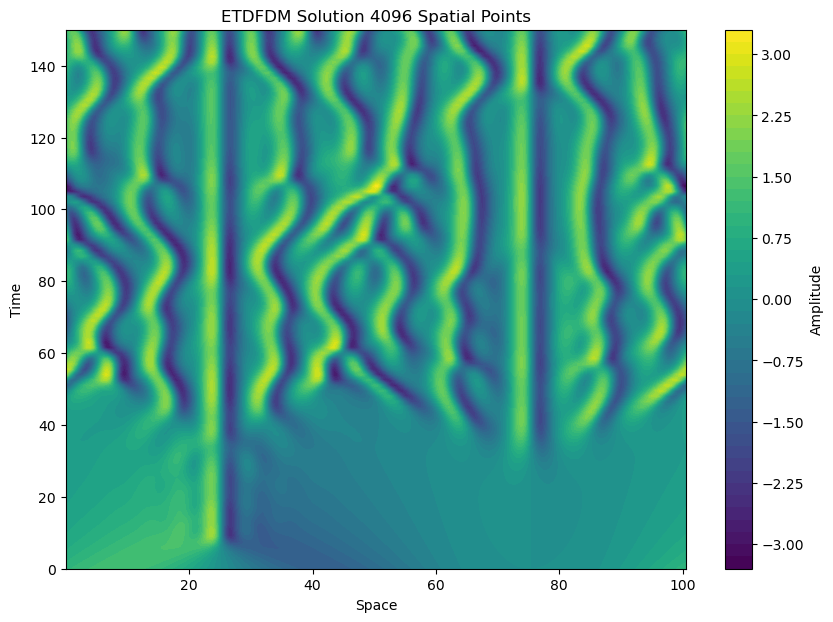

In [151]:

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x1, t1)
contour = ax.contourf(X, T, u1.T, levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('ETDFDM Solution 4096 Spatial Points')

plt.show()

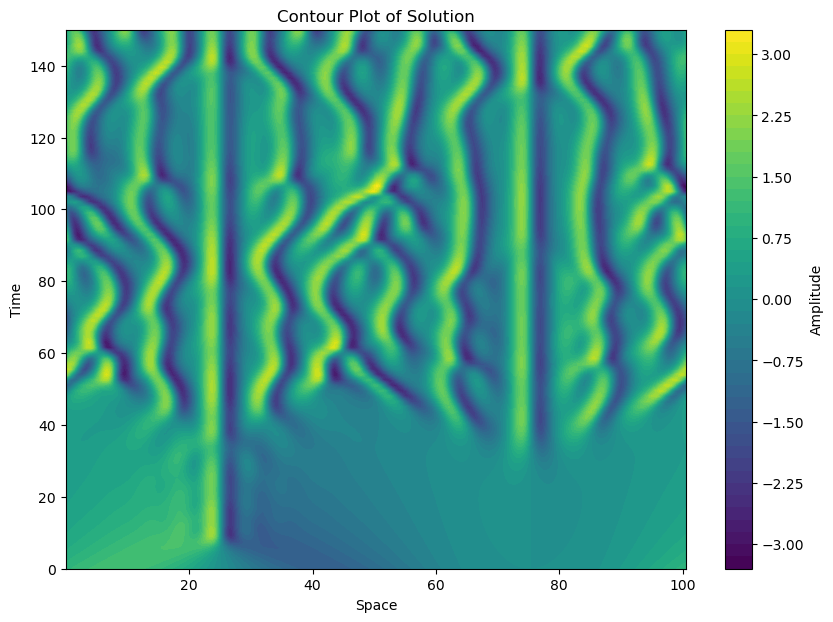

In [ ]:

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x, tt)
contour = ax.contourf(X, T, uu, levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Contour Plot of Solution')

plt.show()

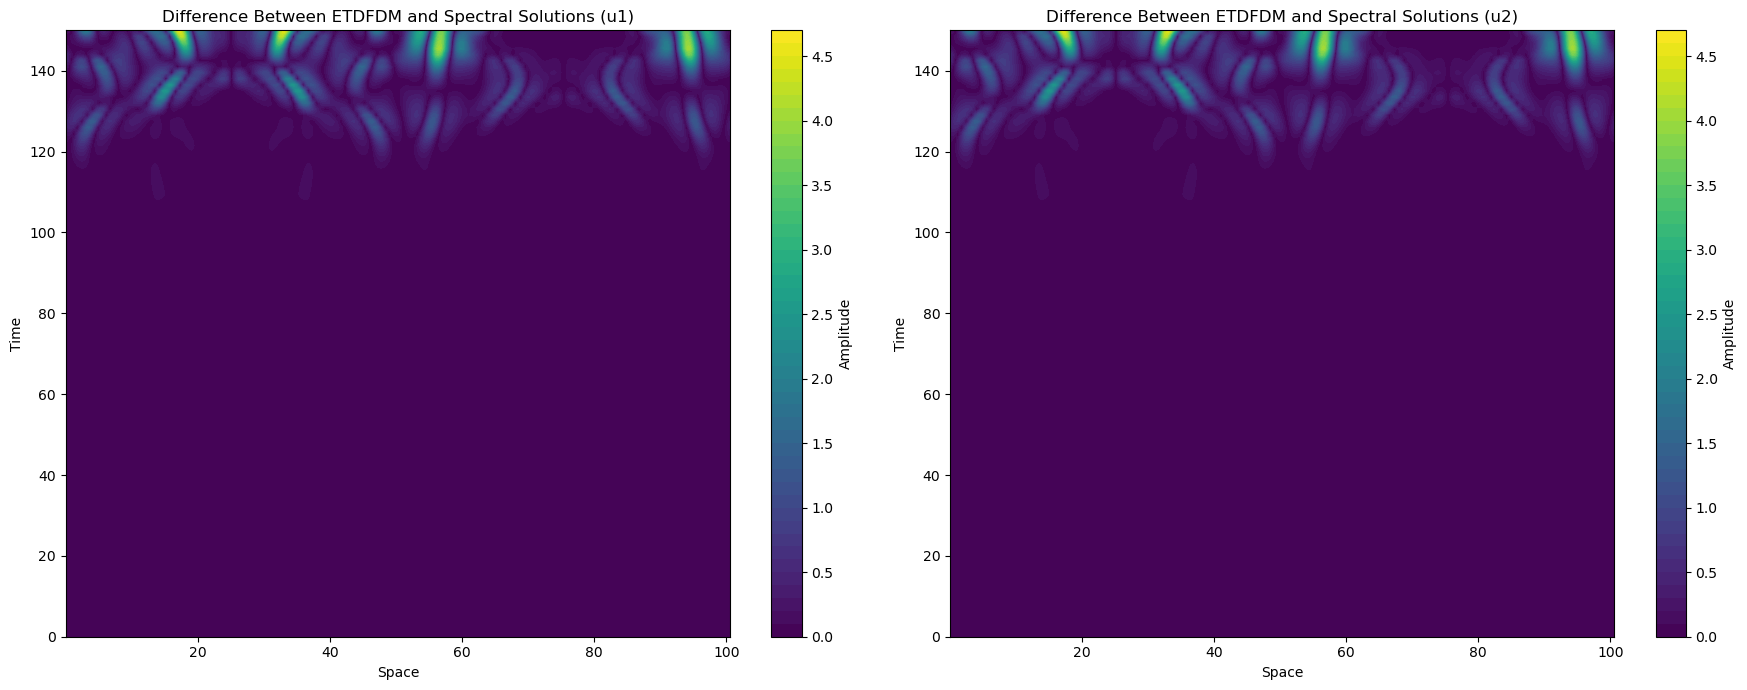

In [ ]:
##plot reference solution at final time, contour plot of solution in space and time, plot of solution at final time
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left subplot: original (with u1) ---
X, T = np.meshgrid(x1, t1)
contour1 = axes[0].contourf(
    X, T, np.abs(uu[:, 2**(15-11)-1::2**(15-11)] - u1.T),
    levels=50, cmap=cm.viridis
)
cbar1 = plt.colorbar(contour1, ax=axes[0])
cbar1.set_label('Amplitude')
axes[0].set_xlabel('Space')
axes[0].set_ylabel('Time')
axes[0].set_title('Difference Between ETDFDM and Spectral Solutions (u1)')

# --- Right subplot: same code but with u2 ---
X, T = np.meshgrid(x2, t2)
contour2 = axes[1].contourf(
    X, T, np.abs(uu[:, 2**(15-11)-1::2**(15-11)] - u2.T),
    levels=50, cmap=cm.viridis
)
cbar2 = plt.colorbar(contour2, ax=axes[1])
cbar2.set_label('Amplitude')
axes[1].set_xlabel('Space')
axes[1].set_ylabel('Time')
axes[1].set_title('Difference Between ETDFDM and Spectral Solutions (u2)')

plt.tight_layout()
plt.show()

C:\Users\Eleph\AppData\Local\Temp\ipykernel_31160\1804135853.py:5: RuntimeWarning: divide by zero encountered in log
  contour = ax.contourf(X, T, np.log(np.abs((uu[:,2**(15-12)-1::2**(15-12)]-u2.T))), levels=50, cmap=cm.inferno)


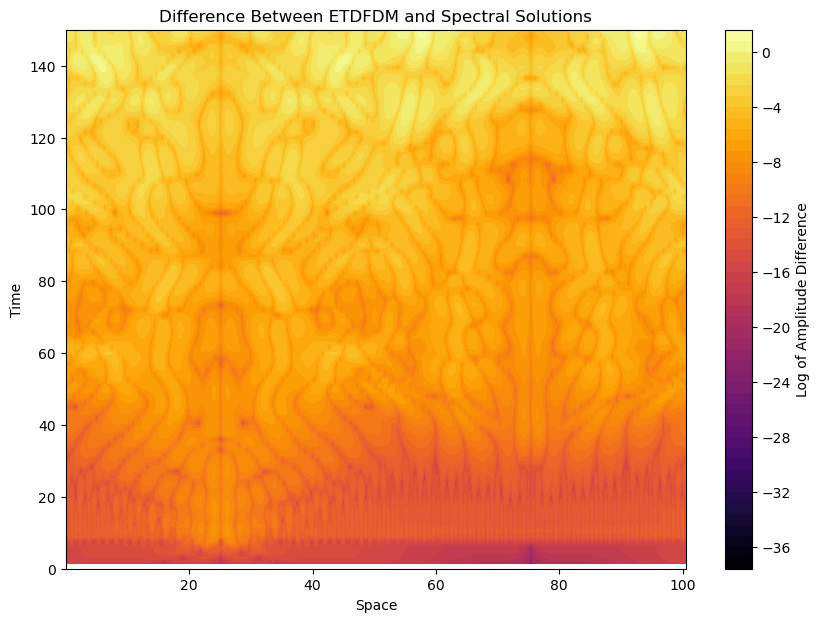

In [29]:
##plot reference solution at final time, contour plot of solution in space and time, plot of solution at final time

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x2,t2)
contour = ax.contourf(X, T, np.log(np.abs((uu[:,2**(15-12)-1::2**(15-12)]-u2.T))), levels=50, cmap=cm.inferno)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Log of Amplitude Difference')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Difference Between ETDFDM and Spectral Solutions')

plt.show()

C:\Users\Eleph\AppData\Local\Temp\ipykernel_31160\1804135853.py:5: RuntimeWarning: divide by zero encountered in log
  contour = ax.contourf(X, T, np.log(np.abs((uu[:,2**(15-12)-1::2**(15-12)]-u2.T))), levels=50, cmap=cm.inferno)


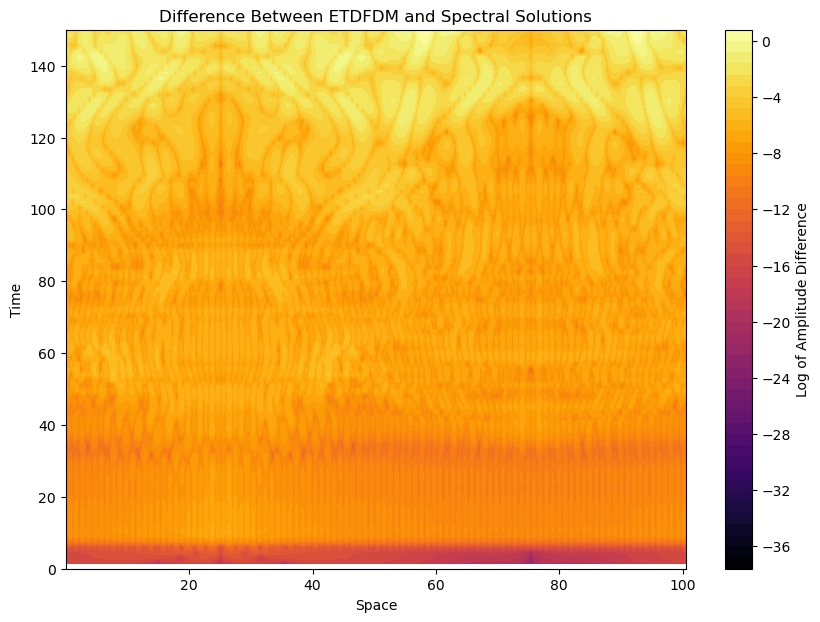

In [31]:
##plot reference solution at final time, contour plot of solution in space and time, plot of solution at final time

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x2,t2)
contour = ax.contourf(X, T, np.log(np.abs((uu[:,2**(15-12)-1::2**(15-12)]-u2.T))), levels=50, cmap=cm.inferno)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Log of Amplitude Difference')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Difference Between ETDFDM and Spectral Solutions')

plt.show()

In [82]:

x2,t2,u2,time2 = ETDFDM_KS_FFT(2**12, h = 1/4)

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
ETD-RK4 coefficients computed. Starting time-stepping...
E eigenvalues: 1.064295339485486
Q max value: 0.0020236479001778072
E2 max value: 0.013544484993750005
Any NaNs in Q? False
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have completed 0.5
you have completed 0.6
you have completed 0.7
you have completed 0.8
you have completed 0.9
you have completed 1.0
ETD_KS execution time: 143.31889820098877 seconds


C:\Users\Eleph\AppData\Local\Temp\ipykernel_31160\1316097413.py:12: RuntimeWarning: divide by zero encountered in log
  ax.plot(t2, np.log(vec_norm), color="navy", linewidth=2)


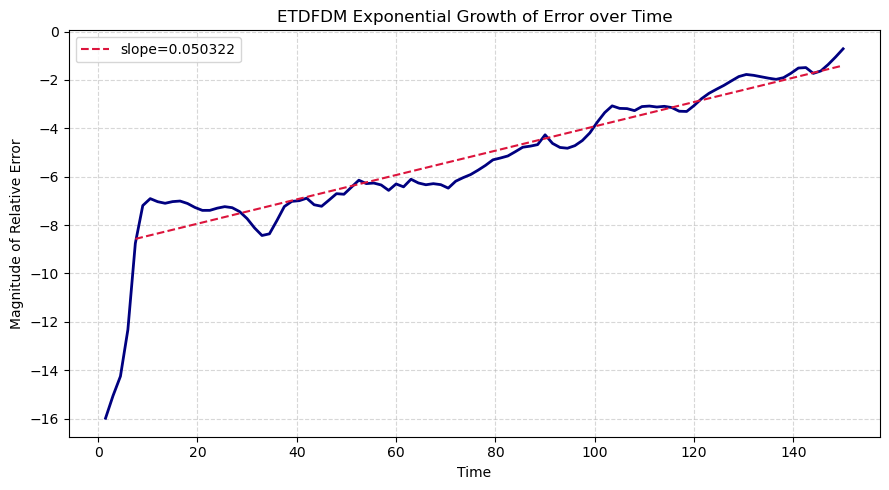

In [93]:
diff = uu[:, 2**(15-12)-1::2**(15-12)] - u2.T
vec_norm = np.linalg.norm(diff, axis=1)/np.linalg.norm(uu[:, 2**(15-12)-1::2**(15-12)], axis=1)

y = np.log(np.clip(vec_norm, 1e-12, None))
mask = (t2 >= 7) & (t2 <= 150)
coef = np.polyfit(t2[mask], y[mask], 1)      # [slope, intercept]
slope, intercept = coef
y_fit = np.polyval(coef, t2[mask])


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t2, np.log(vec_norm), color="navy", linewidth=2)
ax.plot(t2[mask], y_fit, "--", label=f"slope={slope:.6f}", color="crimson")
ax.set_xlabel("Time")
ax.set_ylabel("Magnitude of Relative Error")
ax.set_title("ETDFDM Exponential Growth of Error over Time")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("Lyapunov.pdf")
plt.show()


In [ ]:
slope

np.float64(0.07096158280831323)

slope = 7.096158e-02, intercept = -6.838024e+00


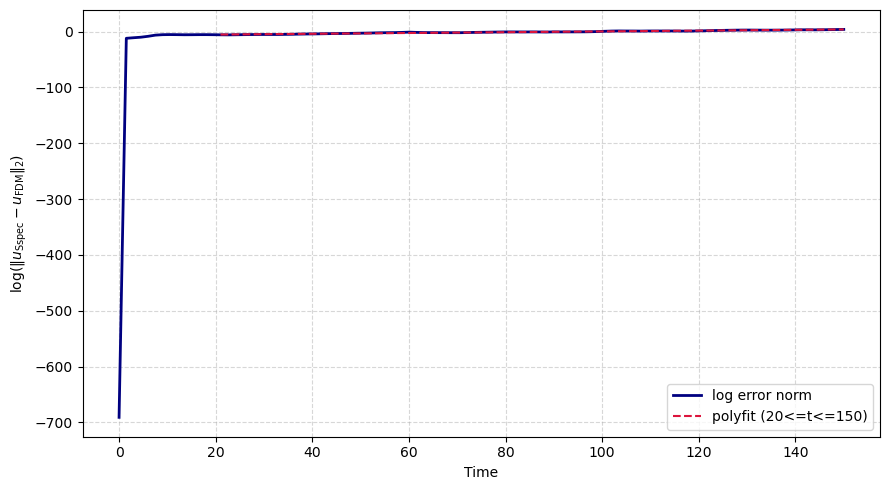

In [ ]:
mask = (t2 >= 20) & (t2 <= 150)

y = np.log(np.clip(vec_norm, 1e-300, None))  # avoid log(0)
coef = np.polyfit(t2[mask], y[mask], 1)      # [slope, intercept]
slope, intercept = coef

print(f"slope = {slope:.6e}, intercept = {intercept:.6e}")

# optional: overlay fitted line
y_fit = np.polyval(coef, t2[mask])
plt.figure(figsize=(9, 5))
plt.plot(t2, y, label="log error norm", color="navy", linewidth=2)
plt.plot(t2[mask], y_fit, "--", label="polyfit (20<=t<=150)", color="crimson")
plt.xlabel("Time")
plt.ylabel(r"$\log(\|u_{\mathrm{Sspec}} - u_{\mathrm{FDM}}\|_2)$")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def circulant_inverse_from_Aeig(z, lamA, tol=1e-12):
    """
    Return (zI - A)^(-1) for circulant A using FFT eigenvalues lamA = fft(first_col(A)).
    """
    denom = z - lamA
    inv_first_col = np.fft.ifft(1.0 / denom)
    return circulant(inv_first_col)


In [40]:
def ETDFDM_KS_FFT2(N,h = 1/4):
    time_start = time.time()

    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")

    I = np.eye(N)
    ##Linear operator L:
    L = -(D2+D4)

    ##ETD quantities

    M = 128

    r = 20 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    
    # FFT eigenvalues of circulant A
    a_eigs = np.fft.fft(A[:,0].astype(complex))
    D1_eigs = np.fft.fft(D1[:,0].astype(complex))

    
    E_eigs  = np.real(np.exp(a_eigs))
    E2_eigs = np.real(np.exp(a_eigs / 2))

    
    Q_eigs  = np.zeros(N, dtype=complex)
    f1_eigs = np.zeros(N, dtype=complex)
    f2_eigs = np.zeros(N, dtype=complex)
    f3_eigs = np.zeros(N, dtype=complex)
    print("Computing ETD-RK4 coefficients...")
    for j in range(M):
        z = r[j]
        d = 1.0 / (z - a_eigs)          # eigenvalues of (zI - A)^{-1}, shape (N,)

        Q_eigs  += h * d * (np.exp(z/2) - 1)
        f1_eigs += h * d * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2_eigs += h * d * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3_eigs += h * d * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q_eigs  = np.real(Q_eigs)  / M
    f1_eigs = np.real(f1_eigs) / M
    f2_eigs = np.real(f2_eigs) / M
    f3_eigs = np.real(f3_eigs) / M


    def circ_matvec(eigs, v):
        return np.real(np.fft.ifft(eigs * np.fft.fft(v)))


    

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 150
    nmax = round(tmax / h)
    nplt = max(1,int(np.floor((tmax / 100) / h)))

    for n in range(1, nmax + 1):
        t = n * h
        
        
        
        Nu = -u * circ_matvec(D1_eigs, u)
        a  = circ_matvec(E2_eigs, u)  + circ_matvec(Q_eigs,  Nu)
        Na = -a * circ_matvec(D1_eigs, a)

        b  = circ_matvec(E2_eigs, u)  + circ_matvec(Q_eigs,  Na)
        Nb = -b * circ_matvec(D1_eigs, b)

        c  = circ_matvec(E2_eigs, a)  + circ_matvec(Q_eigs,  2*Nb - Nu)
        Nc = -c * circ_matvec(D1_eigs, c)

        u  = circ_matvec(E_eigs, u) + circ_matvec(f1_eigs, Nu) \
           + 2*circ_matvec(f2_eigs, Na + Nb) + circ_matvec(f3_eigs, Nc)

        if n % nplt == 0:
            #print("Saving at t = ", t)
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            if n%(10*nplt) == 0:
                print("you have completed", n/nmax)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_KS execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]

In [43]:

x2,t2,u2,time2 = ETDFDM_KS_FFT2(2**12, h = 1/16)

Linear operator constructed. Computing ETD-RK4 coefficients...
Computing ETD-RK4 coefficients...
you have completed 0.1
you have completed 0.2
you have completed 0.3
you have completed 0.4
you have completed 0.5
you have completed 0.6
you have completed 0.7
you have completed 0.8
you have completed 0.9
you have completed 1.0
ETD_KS execution time: 2.7581655979156494 seconds


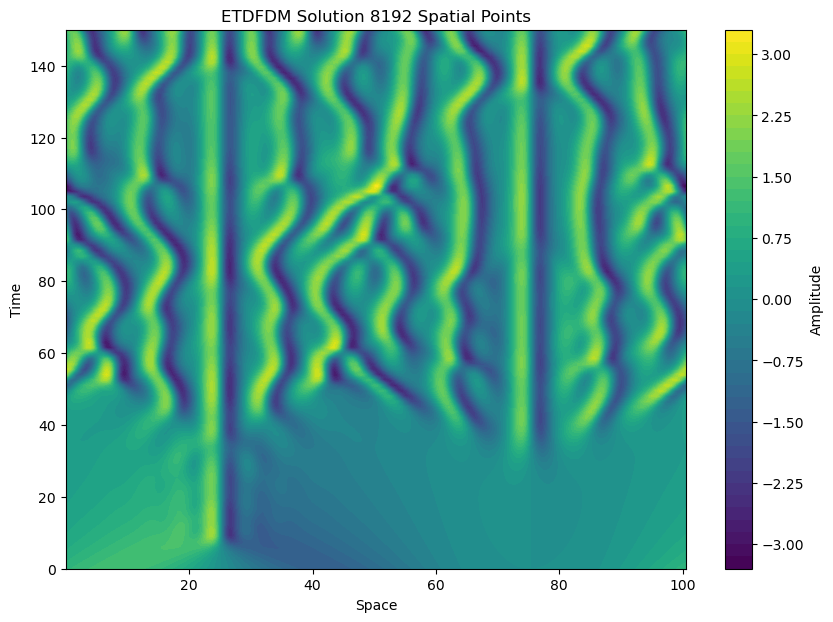

In [ ]:

fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x2, t2)
contour = ax.contourf(X, T, u2.T, levels=50, cmap=cm.viridis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')

# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('ETDFDM Solution 8192 Spatial Points')

plt.show()

In [ ]:
N = 5
D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

D1[0,-1] = -1
D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
D4[-1,0] = D4[0,-1] = -4

In [ ]:
A = D2 + D4

Aexp_default = expm(A)

Aexp_fft = np.real(circulant(np.fft.ifft(np.exp(np.fft.fft(A[:,0])))))

In [ ]:
np.max(np.abs(Aexp_default - Aexp_fft))

np.float64(1.9463186617940664e-10)

In [ ]:
Aexp_fft

array([[ 5197.9218201 , -4204.08712001,  1605.62620996,  1605.62620996,
        -4204.08712001],
       [-4204.08712001,  5197.9218201 , -4204.08712001,  1605.62620996,
         1605.62620996],
       [ 1605.62620996, -4204.08712001,  5197.9218201 , -4204.08712001,
         1605.62620996],
       [ 1605.62620996,  1605.62620996, -4204.08712001,  5197.9218201 ,
        -4204.08712001],
       [-4204.08712001,  1605.62620996,  1605.62620996, -4204.08712001,
         5197.9218201 ]])

In [ ]:
Aexp_default

array([[ 5197.9218201 , -4204.08712001,  1605.62620996,  1605.62620996,
        -4204.08712001],
       [-4204.08712001,  5197.9218201 , -4204.08712001,  1605.62620996,
         1605.62620996],
       [ 1605.62620996, -4204.08712001,  5197.9218201 , -4204.08712001,
         1605.62620996],
       [ 1605.62620996,  1605.62620996, -4204.08712001,  5197.9218201 ,
        -4204.08712001],
       [-4204.08712001,  1605.62620996,  1605.62620996, -4204.08712001,
         5197.9218201 ]])